# Stage 4. JMA-LoRA, rank sweep
### CB1 (six-class) | Gemma-2-9B-it | W = W(I + UV) + AB

The proposed joint formulation, trained with both adaptation paths active. Sweeps r in
{4, 8, 16, 32}, selects the rank on the **validation** partition, and measures the same
rank-preservation diagnostics as Stage 3.

**Reported in:** Sec. 4.5 and Sec. 4.9 of the paper, the S4 column of Table 3, Table 4, and Table 8.

**Result.** Validation selects r = 8 (0.9189 validation Macro F1), giving a test Macro F1 of
0.9044 with 18,945,024 trainable parameters. Note that r = 4 attains a marginally higher test
score, 0.9064, but a lower validation score; the reported configuration is the one validation
selects.

**How to run.** Run Step 1, restart the runtime, then run the remaining steps in order.

In [1]:
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "scikit-learn" \
    tqdm matplotlib seaborn

import importlib.metadata as md
for p in ["torch","transformers","peft","bitsandbytes","accelerate","datasets","numpy","pandas"]:
    try:    print(f"  {p:<16} {md.version(p)}")
    except: print(f"  {p:<16} NOT INSTALLED")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
  torch            2.11.0+cu128
  transformers     4.51.3
  peft             0.20.0
  bitsandbytes     0.50.1
  accelerate       1.14.0
  datasets         4.0.0
  numpy            2.1.3
  pandas           2.2.3


---
## Step 2: Import Libraries and Initial Setup

**Gemma-2-9B requires HF token** — add it via Colab Secrets (key icon in sidebar).


In [1]:
import os, random, collections, re
from typing import Dict, List
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import bitsandbytes.functional as bnb_F
import bitsandbytes as bnb
from google.colab import drive, userdata

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

def load_hf_token():
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add via Colab Secrets.")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()
drive.mount('/content/drive')
print("✓ Google Drive mounted.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Gemma-2-9B specific:** batch=4, HF token required, output dir updated.


In [2]:
MODEL_NAME   = "google/gemma-2-9b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 32]

NUM_EPOCHS       = 1
LEARNING_RATE    = 2e-4
TRAIN_BATCH_SIZE = 4      # 9B model — safe batch with dual adapter on A100
EVAL_BATCH_SIZE  = 16
WEIGHT_DECAY     = 0.01
EVAL_STEPS       = 200
LOGGING_STEPS    = 50
OUTPUT_DIR       = "/content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying': 0, 'gender': 1, 'religion': 2,
    'ethnicity': 3, 'age': 4, 'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 4a — Generalised LoRA")
print(f"  Formula  : Wf = W(I + UV) + AB")
print(f"  Model    : {MODEL_NAME}")
print(f"  HF token : Required ✓")
print(f"  Batch    : train={TRAIN_BATCH_SIZE} | eval={EVAL_BATCH_SIZE}")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: 1.0")
print(f"  Rank sweep: {RANK_SWEEP}")
print()
print("  ── Stage references (Gemma-2-9B CB1) ──")
print("  S2: r=4: 0.8951 | r=8: 0.8954 | r=16: 0.8986 | r=32: 0.9010★  ↑ monotonic")
print("  S3: r=4: 0.8757 | r=8: 0.8925 | r=16: 0.8937 | r=32: 0.8944   ↑ monotonic")
print("  Eff.Rank: 2815.98 — perfectly constant (strongest Prop 1 validation)")
print("  ★ TARGET: beat S2 r=32 F1=0.9010 — the overall CB1 champion")


✓ Configuration loaded.
  Stage    : 4a — Generalised LoRA
  Formula  : Wf = W(I + UV) + AB
  Model    : google/gemma-2-9b-it
  HF token : Required ✓
  Batch    : train=4 | eval=16
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Rank sweep: [4, 8, 32]

  ── Stage references (Gemma-2-9B CB1) ──
  S2: r=4: 0.8951 | r=8: 0.8954 | r=16: 0.8986 | r=32: 0.9010★  ↑ monotonic
  S3: r=4: 0.8757 | r=8: 0.8925 | r=16: 0.8937 | r=32: 0.8944   ↑ monotonic
  Eff.Rank: 2815.98 — perfectly constant (strongest Prop 1 validation)
  ★ TARGET: beat S2 r=32 F1=0.9010 — the overall CB1 champion


---
## Step 4: Text Preprocessing

Identical to all prior stages — verbatim copy for reproducible split.

In [3]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text

print("Before:", "RT @user123: Check this out http://example.com !!! @someone is so dumb")
print("After: ", preprocess_text_for_llm("RT @user123: Check this out http://example.com !!! @someone is so dumb"))
print("\n✓ Preprocessing function defined.")


Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

Identical to all prior stages.

In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)
df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")
df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
corrupt_mask = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {corrupt_mask.sum()} corrupt rows → {len(df):,} remaining")
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")
text_label_counts = df.groupby('text')['label'].nunique()
conflicting = text_label_counts[text_label_counts > 1].index
df = df[~df['text'].isin(conflicting)].reset_index(drop=True)
print(f"[5] Removed annotation-conflict rows → {len(df):,} remaining")
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before-len(df):,} exact duplicates → {len(df):,} remaining")
before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before-len(df):,} short texts → {len(df):,} remaining")
assert len(set(df['label'].unique()) - set(LABEL_MAPPING.keys())) == 0

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
print(f"\n  Imbalance ratio: {counts.max()/counts.min():.2f}×")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio: 1.37×


---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

Identical — seed=42, same test set across all stages.

In [5]:
print("═" * 60)
print("DATASET SPLITTING — 75% train / 25% test")
print("═" * 60)
train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs = tfidf_matrix[:len(train_val_df)]
test_vecs = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end = min(start+500, len(test_df))
    batch_sims = cosine_similarity(test_vecs[start:end], train_vecs)
    leaked_mask = batch_sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked = test_df.loc[leaked_indices]
    test_df = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked], ignore_index=True)
    print(f"    Moved → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

overlap = set(train_val_df['text'].tolist()) & set(test_df['text'].tolist())
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("    ✓ Data leakage assertion passed.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
print(f"\n[3] Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"    ✓ Test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")


════════════════════════════════════════════════════════════
DATASET SPLITTING — 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved → Train+Val: 33,004 | Test: 10,330
    ✓ Data leakage assertion passed.

[3] Train: 29,703 | Val: 3,301 | Test: 10,330
    ✓ Test = 23.8% (target: 25.0%)


---
## Step 7: Class Weights

Identical to all prior stages.

In [6]:
def get_class_weights(df, label_col='label'):
    counts = df[label_col].value_counts()
    total = len(df); n_classes = len(LABEL_MAPPING)
    weights = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights:")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank — Generalised LoRA (all bugs fixed)

SVD on `Wf = W + W@(UV) + A@B`. Fixed: `type(module).__name__` check, better error diagnostics.
Gemma-2-9B reference: 2815.98 (perfectly constant across all ranks and stages).


In [7]:
def calculate_effective_rank_generalised(model, threshold_ratio=1e-3):
    full_ranks, uv_ranks, ab_ranks, per_layer = [], [], [], []
    skipped = 0

    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer':
            continue
        try:
            U = module.lora_U.data.float(); V = module.lora_V.data.float()
            A = module.lora_A.data.float(); B = module.lora_B.data.float()
            UV = U @ V; AB = A @ B

            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)

            weight_obj = module.inner.weight
            try:
                if hasattr(weight_obj, 'quant_state'):
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                else:
                    W = weight_obj.data.float()
            except Exception as e:
                if skipped == 0: print(f"  ℹ First dequant error: {type(e).__name__}: {e}")
                skipped += 1; continue

            if W.shape[0] == module.m and W.shape[1] == module.n:
                pass
            elif W.shape[0] == module.n and W.shape[1] == module.m:
                W = W.T.contiguous()
            else:
                if skipped == 0: print(f"  ℹ Shape mismatch: W={list(W.shape)}, m={module.m}, n={module.n}")
                skipped += 1; continue

            Wf = W + W @ UV + AB
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab})
        except Exception:
            skipped += 1; continue

    if skipped > 0: print(f"  ℹ {skipped} layers skipped")
    if not full_ranks: print("  ⚠ No GeneralisedLoRALayer found")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks)) if uv_ranks else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks)) if ab_ranks else 0.0,
        "layer_count": len(full_ranks), "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_generalised() defined.")
print("  Gemma-2-9B reference: 2815.98 (perfectly constant in S2 and S3)")


✓ calculate_effective_rank_generalised() defined.
  Gemma-2-9B reference: 2815.98 (perfectly constant in S2 and S3)


---
## Step 9: Evaluation Metrics

Identical to all prior stages.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}

def evaluate_dataset(y_true, y_pred, dataset_name):
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'balanced_accuracy': bal_accuracy, 'mcc': mcc}

def make_predictions(model, df_test, tokenizer, batch_size=32):
    model.eval(); all_preds = []
    texts = df_test['text'].tolist()
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(texts[start:start+batch_size], padding='max_length',
                        truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
    df_out = df_test.copy(); df_out['predictions'] = all_preds
    return df_out

print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.


---
## Step 10: Stability System + Custom Trainer

Identical to Stages 2–4 Llama/Mistral. 2-panel stability plot.

In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []; self.val_metrics = collections.defaultdict(list); self.val_steps = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs: self.train_losses.append((state.global_step, float(logs['loss'])))
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for k, v in metrics.items(): self.val_metrics[k.replace('eval_','')].append(float(v))
    def get_stability_report(self):
        report = {}
        if self.train_losses:
            arr = np.array([l for (_,l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall'] = float(np.std(arr))
            report['loss_cv_overall'] = float(np.std(arr)/np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for m, vals in self.val_metrics.items():
            if len(vals) > 1:
                a = np.array(vals)
                report[f'val_{m}_std'] = float(np.std(a)); report[f'val_{m}_range'] = float(a.max()-a.min())
                report[f'val_{m}_best'] = float(a.max()); report[f'val_{m}_final'] = float(a[-1])
        report['stability_score'] = round((report.get('loss_cv_overall',0)*0.5) + (report.get('val_f1_std',0)*0.5), 6)
        return report
    def plot_stability_curves(self, stage_label='Stage 4', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps = [s for (s,_) in self.train_losses]; losses = [l for (_,l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            w = min(20, len(losses))
            if len(losses) >= w:
                roll = np.convolve(losses, np.ones(w)/w, mode='valid')
                ax1.plot(steps[w-1:], roll, color='navy', linewidth=2.2, label=f'Rolling mean (w={w})')
            ax1.set_title(f'{stage_label}\nTraining Loss'); ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps:
            ax2r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1v = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1v, 'o-', color='forestgreen', linewidth=2, markersize=5, label='Macro F1')
                mu, sd = float(np.mean(f1v)), float(np.std(f1v))
                ax2.axhline(mu, color='forestgreen', linestyle=':', alpha=0.6)
                ax2.fill_between(self.val_steps, [mu-sd]*len(self.val_steps), [mu+sd]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={sd:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen'); ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2r and 'mcc' in self.val_metrics:
                ax2r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                          linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2r.set_ylabel('MCC', color='darkorange'); ax2r.tick_params(axis='y', labelcolor='darkorange')
            l1, lb1 = ax2.get_legend_handles_labels()
            l2, lb2 = (ax2r.get_legend_handles_labels() if ax2r else ([], []))
            ax2.legend(l1+l2, lb1+lb2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics'); ax2.set_xlabel('Step'); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight'); print(f"✓ Saved → {save_path}")
        plt.show()

class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels"); outputs = model(**inputs); logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device)) if self.class_weights is not None else nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✓ StabilityCallback, CustomTrainer defined.")


✓ StabilityCallback, CustomTrainer defined.


---
## Step 11: Generalised LoRA Adapter + Training Function

All bugs fixed. Parameters initialised on `inner.weight.device`. No `.to(dev)` in forward.

**Gemma-2-9B specific:** HF token passed to from_pretrained().


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# RANK-PRESERVATION DIAGNOSTICS
# Proposition 2 requires ||UV||_2 < 1 for I+UV to be invertible.
# The paper asserts this; this measures whether training actually stayed there.
# No extra training runs: it reads the model already in memory.
# ═══════════════════════════════════════════════════════════════════════════
def measure_rank_conditions(model):
    rows = []
    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer':
            continue
        try:
            U = module.lora_U.detach().float()      # (n, r)
            V = module.lora_V.detach().float()      # (r, n)
            UV = (U @ V) * module.scaling           # scaling applied as in forward
            n  = UV.shape[0]
            L1 = torch.eye(n, device=UV.device, dtype=UV.dtype) + UV
            s_uv = torch.linalg.svdvals(UV)
            s_l1 = torch.linalg.svdvals(L1)
            rows.append({
                'layer': name,
                'spectral_norm_UV': float(s_uv[0]),
                'satisfies_prop2':  bool(float(s_uv[0]) < 1.0),
                'sigma_min_L1':     float(s_l1[-1]),
                'sigma_max_L1':     float(s_l1[0]),
                'cond_L1':          float(s_l1[0] / max(float(s_l1[-1]), 1e-12)),
            })
        except Exception as e:
            print(f'   [skip] {name}: {e}')
    if not rows:
        return {}, []
    import numpy as _np
    a = lambda k: _np.array([r[k] for r in rows])
    summary = {
        'layers_measured':              len(rows),
        'max_spectral_norm_UV':         float(a('spectral_norm_UV').max()),
        'mean_spectral_norm_UV':        float(a('spectral_norm_UV').mean()),
        'frac_layers_satisfying_prop2': float(a('satisfies_prop2').mean()),
        'min_sigma_min_L1':             float(a('sigma_min_L1').min()),
        'max_cond_L1':                  float(a('cond_L1').max()),
        'mean_cond_L1':                 float(a('cond_L1').mean()),
    }
    print('\n[6b] Rank-preservation conditions (Proposition 2):')
    print(f'      layers measured      : {summary["layers_measured"]}')
    print(f'      max ||UV||_2         : {summary["max_spectral_norm_UV"]:.4f}   (needs < 1)')
    print(f'      satisfying Prop 2    : {100*summary["frac_layers_satisfying_prop2"]:.1f}% of layers')
    print(f'      min sigma_min(I+UV)  : {summary["min_sigma_min_L1"]:.4e}')
    print(f'      max condition number : {summary["max_cond_L1"]:.2f}')
    if summary['frac_layers_satisfying_prop2'] < 1.0:
        print('      NOTE: training left the Proposition 2 regime in some layers.')
        print('            Report this. It is a finding, not a failure.')
    return summary, rows

print("✓ measure_rank_conditions() defined.")


✓ measure_rank_conditions() defined.


In [11]:
class GeneralisedLoRALayer(nn.Module):
    """
    Dual adapter: Wf = W(I + UV) + AB
    Forward: y = W·x + scaling·W·(U·(V·x)) + scaling·A·(B·x)
    Init: V=0, B=0 → Wf=W at start. Scaling = alpha/rank = 1.0.
    Params on inner.weight.device from init — no .to() in forward.
    """
    def __init__(self, base_layer, rank, dropout=0.05, alpha=None):
        super().__init__()
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank

        inner = base_layer.base_layer if hasattr(base_layer, 'base_layer') else base_layer
        if hasattr(inner, 'in_features'):
            n, m = inner.in_features, inner.out_features
        elif hasattr(inner, 'weight'):
            n, m = inner.weight.shape[1], inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine dims from {type(inner)}")

        self.n = n; self.m = m; self.inner = inner
        _dev = self.inner.weight.device

        self.lora_U = nn.Parameter(torch.empty(n, rank, device=_dev))
        self.lora_V = nn.Parameter(torch.zeros(rank, n, device=_dev))
        self.lora_A = nn.Parameter(torch.empty(m, rank, device=_dev))
        self.lora_B = nn.Parameter(torch.zeros(rank, n, device=_dev))

        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()
        for param in self.inner.parameters(): param.requires_grad = False

    def forward(self, x):
        base_out = self.inner(x)
        x_drop = self.dropout(x)

        lora_vx  = x_drop @ self.lora_V.T
        lora_uvx = lora_vx @ self.lora_U.T
        mult_out = self.inner(lora_uvx)

        lora_bx = x_drop @ self.lora_B.T
        add_out = lora_bx @ self.lora_A.T

        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    from peft.tuners.lora import LoraLayer
    if alpha is None: alpha = rank
    replaced = 0
    module_dict = dict(model.named_modules())

    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer): continue
        if not any(name.endswith(f'.{t}') or name == t for t in target_modules): continue
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent = module_dict.get(parts[0])
            if parent is None: continue
            attr_name = parts[1]
        else:
            parent = model; attr_name = name
        gen_layer = GeneralisedLoRALayer(module, rank=rank, dropout=dropout, alpha=alpha)
        setattr(parent, attr_name, gen_layer)
        replaced += 1

    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return model, trainable, total


def run_generalised_lora(train_df, val_df, test_df, lora_rank, run_label=''):
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label = run_label or f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4 — GENERALISED LoRA  |  {label}')
    print(f'  Model: {MODEL_NAME}  |  Rank: {lora_rank}  |  Scaling: 1.0')
    print(f'  Formula: Wf = W(I + UV) + AB   [both paths active]')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    print('[2] Preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for s in [train_m, val_m, test_m]:
        s['label'] = s['label'].map(LABEL_MAPPING)
        assert s['label'].notnull().all()
    hf_train = Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha, target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')

    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=quant_config, num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16, device_map='auto', token=HF_TOKEN)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    print('   PEFT shell registered.')

    print('[4] Injecting GeneralisedLoRALayer...')
    model, trainable, total = apply_generalised_lora_over_peft(
        model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_alpha)
    print(f'   Trainable: {trainable:,} | Total: {total:,} | {100*trainable/total:.4f}%')

    class_weights = get_class_weights(train_df)

    training_args = TrainingArguments(
        output_dir=run_dir, num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS, save_strategy='no',
        load_best_model_at_end=False,
        fp16=False, bf16=True,
        report_to='none', remove_unused_columns=False,
    )

    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, callbacks=[stability_cb],
        class_weights=class_weights)

    print(f'\n[5] Training (Wf = W(I+UV) + AB, r={lora_rank})...')
    train_result = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    stab_report = stability_cb.get_stability_report()
    # ---- VALIDATION scores: the metric rank selection must use (Rev 5a, 6b) ----
    # compute_metrics returns 'f1', so the stability report keys are val_f1_*
    val_best  = stab_report.get('val_f1_best',  float('nan'))
    val_final = stab_report.get('val_f1_final', float('nan'))
    print(f'   VALIDATION Macro F1 — best: {val_best:.4f} | final: {val_final:.4f}'
          f'   <-- rank selection uses THIS, not the test score')
    stab_score = stab_report.get('stability_score', float('nan'))
    print(f'   Stability: {stab_score:.4f}', end='  ')
    if stab_score < 0.05: print('✅ Very stable')
    elif stab_score < 0.15: print('🟡 Acceptable')
    else: print('🔴 Unstable')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4 Gemma-2-9B — Generalised LoRA (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png'))

    print('\n[6] Computing effective rank...')
    rank_info = calculate_effective_rank_generalised(model)
    diag, diag_rows = measure_rank_conditions(model)
    print(f'   Eff.Rank Wf: {rank_info["avg_eff_rank_Wf"]:.2f}  ← S2: 2815.98 | S3: 2815.98')
    print(f'   Eff.Rank UV: {rank_info["avg_eff_rank_UV"]:.2f} | AB: {rank_info["avg_eff_rank_AB"]:.2f}')
    print(f'   Layers: {rank_info["layer_count"]}')

    print('\n[7] Evaluating on test set...')
    test_preds = make_predictions(model, test_m, tokenizer)
    eval_results = evaluate_dataset(
        test_m['label'].tolist(), test_preds['predictions'].tolist(), f'Stage4_CB1_{label}')

    row = {
        'model': 'Gemma-2-9B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank, 'trainable_params': trainable,
        'val_macro_f1_best': val_best, 'val_macro_f1_final': val_final,
        'macro_f1': eval_results['macro_f1'], 'mcc': eval_results['mcc'],
        'accuracy': eval_results['accuracy'], 'balanced_accuracy': eval_results['balanced_accuracy'],
        'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
        'stability_score': stab_score, 'train_runtime_s': train_runtime_s,
        **{k: diag.get(k) for k in ('max_spectral_norm_UV','mean_spectral_norm_UV',
                                    'frac_layers_satisfying_prop2','min_sigma_min_L1',
                                    'max_cond_L1','mean_cond_L1')},
    }
    pd.DataFrame([row]).to_csv(os.path.join(run_dir, f'{label}_results.csv'), index=False)
    if diag_rows:
        pd.DataFrame(diag_rows).to_csv(
            os.path.join(run_dir, f'{label}_rank_diagnostics.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}')

    del model, trainer; torch.cuda.empty_cache()

    return {**eval_results, 'lora_rank': lora_rank, 'trainable_params': trainable,
            'val_macro_f1_best': val_best, 'val_macro_f1_final': val_final,
            'rank_diagnostics': diag,
            'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
            'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
            'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
            'stability_score': stab_score, 'stability_report': stab_report,
            'stability_cb': stability_cb, 'train_runtime_s': train_runtime_s}


print("✓ GeneralisedLoRALayer defined.  (device-aware init, no .to() in forward)")
print("✓ apply_generalised_lora_over_peft() defined.  (rsplit fix)")
print("✓ run_generalised_lora() defined.")


✓ GeneralisedLoRALayer defined.  (device-aware init, no .to() in forward)
✓ apply_generalised_lora_over_peft() defined.  (rsplit fix)
✓ run_generalised_lora() defined.


In [12]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False
print("datasets torchvision path disabled:", datasets.config.TORCHVISION_AVAILABLE)

datasets torchvision path disabled: False


## Step 12: Execute — FIRST RUN (r = 4)

Runs `r = 4` alone so that the
validation logging works and measure the true compute cost before committing 10 more hours.


✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r4
  Model: google/gemma-2-9b-it  |  Rank: 4  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.444200,0.957011,0.812481,0.782009,0.778510
400,0.614200,0.510601,0.859739,0.843405,0.835273
600,0.477500,0.889805,0.839443,0.793751,0.815320
800,0.726800,0.541102,0.850651,0.837250,0.825098
1000,0.410400,0.647348,0.859134,0.837936,0.835715
1200,0.630400,0.525482,0.868828,0.848851,0.846911
1400,0.650100,0.523373,0.877310,0.862244,0.854131
1600,0.732400,0.497903,0.892154,0.877560,0.871113
1800,0.481200,0.571581,0.873978,0.858593,0.849169
2000,0.484900,0.533360,0.893972,0.883008,0.874408


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.444200,0.957011,0.812481,0.782009,0.778510
400,0.614200,0.510601,0.859739,0.843405,0.835273
600,0.477500,0.889805,0.839443,0.793751,0.815320
800,0.726800,0.541102,0.850651,0.837250,0.825098
1000,0.410400,0.647348,0.859134,0.837936,0.835715
1200,0.630400,0.525482,0.868828,0.848851,0.846911
1400,0.650100,0.523373,0.877310,0.862244,0.854131
1600,0.732400,0.497903,0.892154,0.877560,0.871113
1800,0.481200,0.571581,0.873978,0.858593,0.849169
2000,0.484900,0.533360,0.893972,0.883008,0.874408


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

   Time: 12145s (3.37 hrs)
   VALIDATION Macro F1 — best: 0.9160 | final: 0.9141   <-- rank selection uses THIS, not the test score
   Stability: 0.2267  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r4/stability_GeneralisedLoRA_r4.png


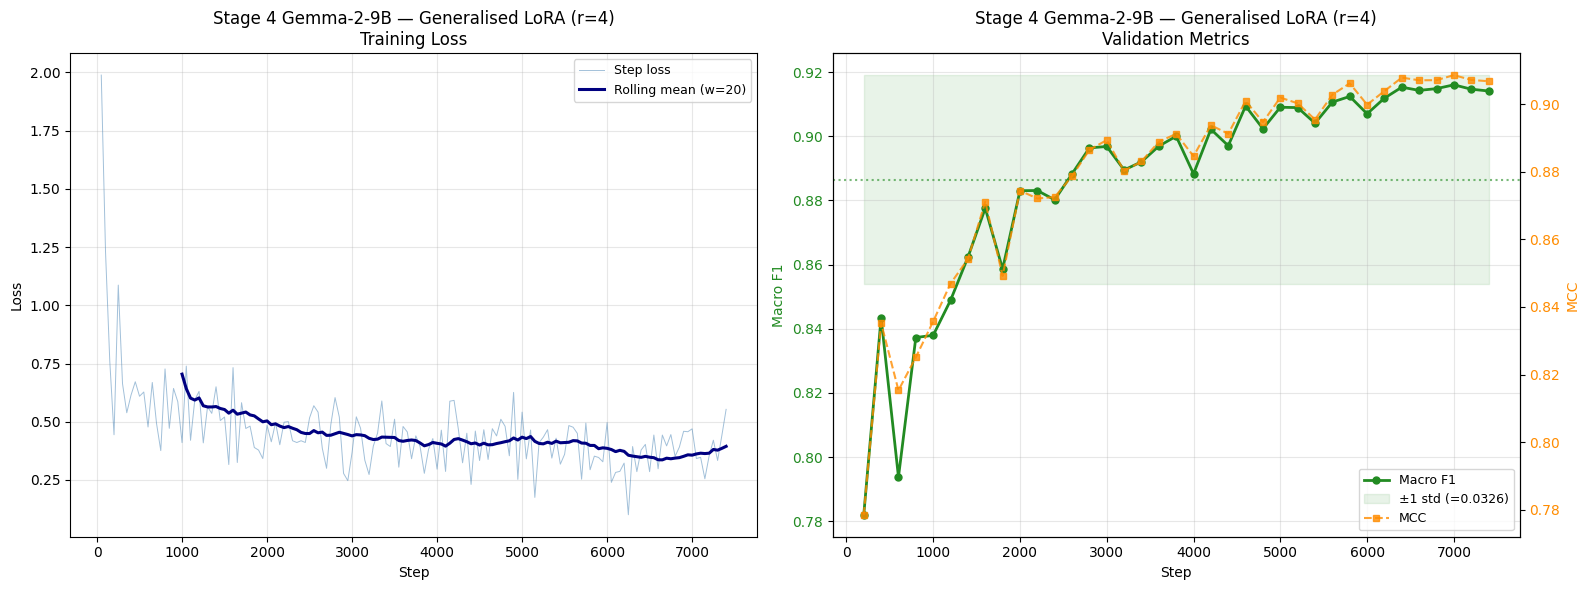


[6] Computing effective rank...


/tmp/ipykernel_1720/1986088909.py:13: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:692.)
  S_uv = torch.linalg.svdvals(UV)



[6b] Rank-preservation conditions (Proposition 2):
      layers measured      : 168
      max ||UV||_2         : 2.2202   (needs < 1)
      satisfying Prop 2    : 31.0% of layers
      min sigma_min(I+UV)  : 3.6773e-01
      max condition number : 7.01
      NOTE: training left the Proposition 2 regime in some layers.
            Report this. It is a finding, not a failure.
   Eff.Rank Wf: 2815.98  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 4.00 | AB: 4.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9170
  Macro F1          : 0.9064  ← PRIMARY METRIC
  Weighted F1       : 0.9170
  Balanced Accuracy : 0.9069
  MCC               : 0.9002  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7866    0.74

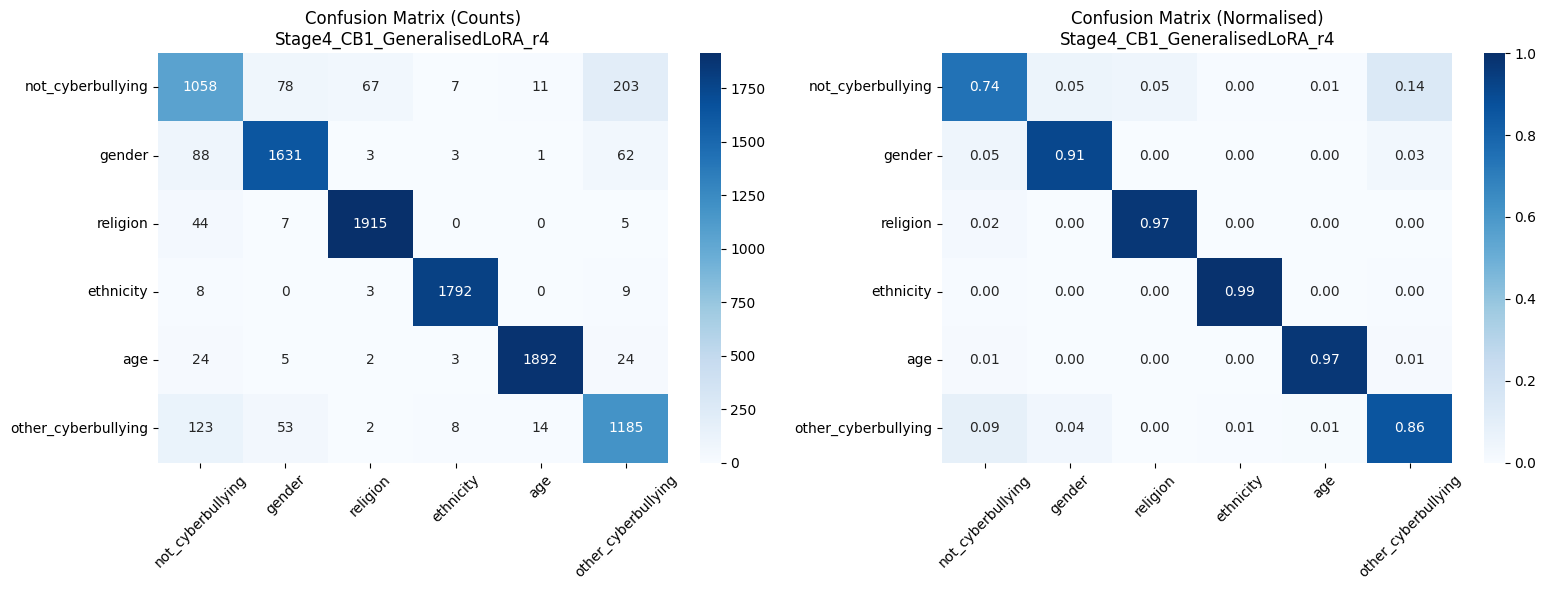


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r4

  RUN 1 COMPLETE — r=4
  VALIDATION Macro F1 : 0.9160   <-- selection metric
  Test Macro F1       : 0.9064   (reported only, not for selection)
  Trainable params    : 9,483,264
  Runtime             : 3.37 hrs

  >> Check your compute unit balance now, then run the sweep cell.


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# RUN 1 OF 4  —  r = 4   (START HERE)
# Run this cell ALONE first. When it finishes, check three things:
#   1. "VALIDATION Macro F1 — best:" prints a real number, not nan
#   2. "max ||UV||_2" prints
#   3. remaining compute units, to get the true units-per-run
# Then run the sweep cell below for r = 8, 16, 32.
# ═══════════════════════════════════════════════════════════════════════════
all_rank_results = {}

res_r4 = run_generalised_lora(
    train_df=train_df, val_df=val_df, test_df=test_df,
    lora_rank=4, run_label='GeneralisedLoRA_r4')
all_rank_results[4] = res_r4

print('\n' + '='*70)
print('  RUN 1 COMPLETE — r=4')
print('='*70)
print(f'  VALIDATION Macro F1 : {res_r4["val_macro_f1_best"]:.4f}   <-- selection metric')
print(f'  Test Macro F1       : {res_r4["macro_f1"]:.4f}   (reported only, not for selection)')
print(f'  Trainable params    : {res_r4["trainable_params"]:,}')
print(f'  Runtime             : {res_r4["train_runtime_s"]/3600:.2f} hrs')
print('\n  >> Check the compute unit balance, then run the sweep cell.')


## Step 13: Rank Sweep — r ∈ {8, 16, 32}

**CHANGED FOR THE REVISION.** Was `{4, 8, 32}` because r=16 ran in Step 12. Now r=4 runs
in Step 12, so this sweeps the other three. Ends by selecting the rank on **validation**.



-------------------------------------------------------
  Rank sweep: r=8
-------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r8
  Model: google/gemma-2-9b-it  |  Rank: 8  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...
   Vocab: 256,000
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.444700,1.000616,0.819449,0.790886,0.787085
400,0.723500,0.546887,0.851863,0.837234,0.827479
600,0.503400,0.865372,0.843078,0.807784,0.815537


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.444700,1.000616,0.819449,0.790886,0.787085
400,0.723500,0.546887,0.851863,0.837234,0.827479
600,0.503400,0.865372,0.843078,0.807784,0.815537
800,0.773400,0.600737,0.839140,0.820811,0.811138
1000,0.462400,0.617713,0.862163,0.840073,0.838887
1200,0.703500,0.488164,0.869736,0.855983,0.844064
1400,0.687200,0.650253,0.847622,0.817047,0.822458
1600,0.778200,0.518279,0.877007,0.858162,0.854815
1800,0.560300,0.546783,0.874583,0.860745,0.850246
2000,0.520600,0.555828,0.877916,0.861061,0.857778


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

   Time: 12472s (3.46 hrs)
   VALIDATION Macro F1 — best: 0.9189 | final: 0.9189   <-- rank selection uses THIS, not the test score
   Stability: 0.2259  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r8/stability_GeneralisedLoRA_r8.png


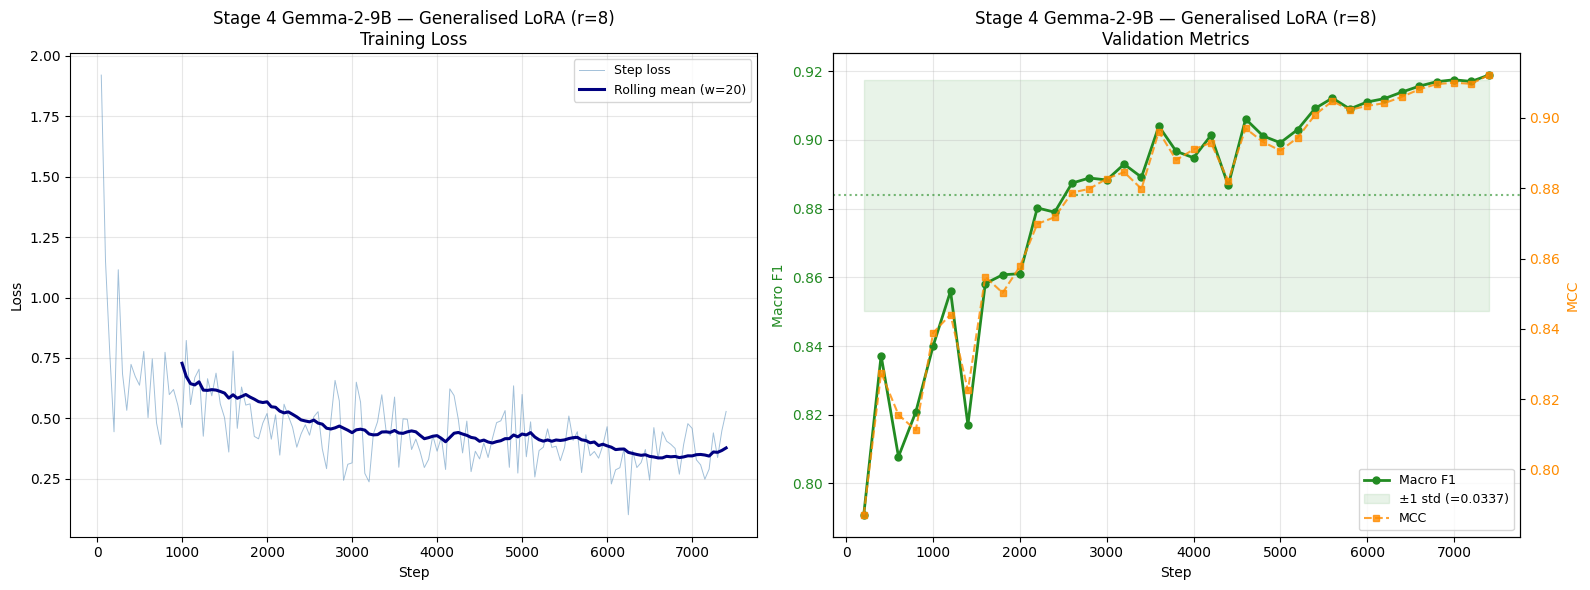


[6] Computing effective rank...

[6b] Rank-preservation conditions (Proposition 2):
      layers measured      : 168
      max ||UV||_2         : 3.3587   (needs < 1)
      satisfying Prop 2    : 3.6% of layers
      min sigma_min(I+UV)  : 2.9639e-01
      max condition number : 12.30
      NOTE: training left the Proposition 2 regime in some layers.
            Report this. It is a finding, not a failure.
   Eff.Rank Wf: 2815.98  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 8.00 | AB: 8.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9155
  Macro F1          : 0.9044  ← PRIMARY METRIC
  Weighted F1       : 0.9151
  Balanced Accuracy : 0.9050
  MCC               : 0.8984  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not

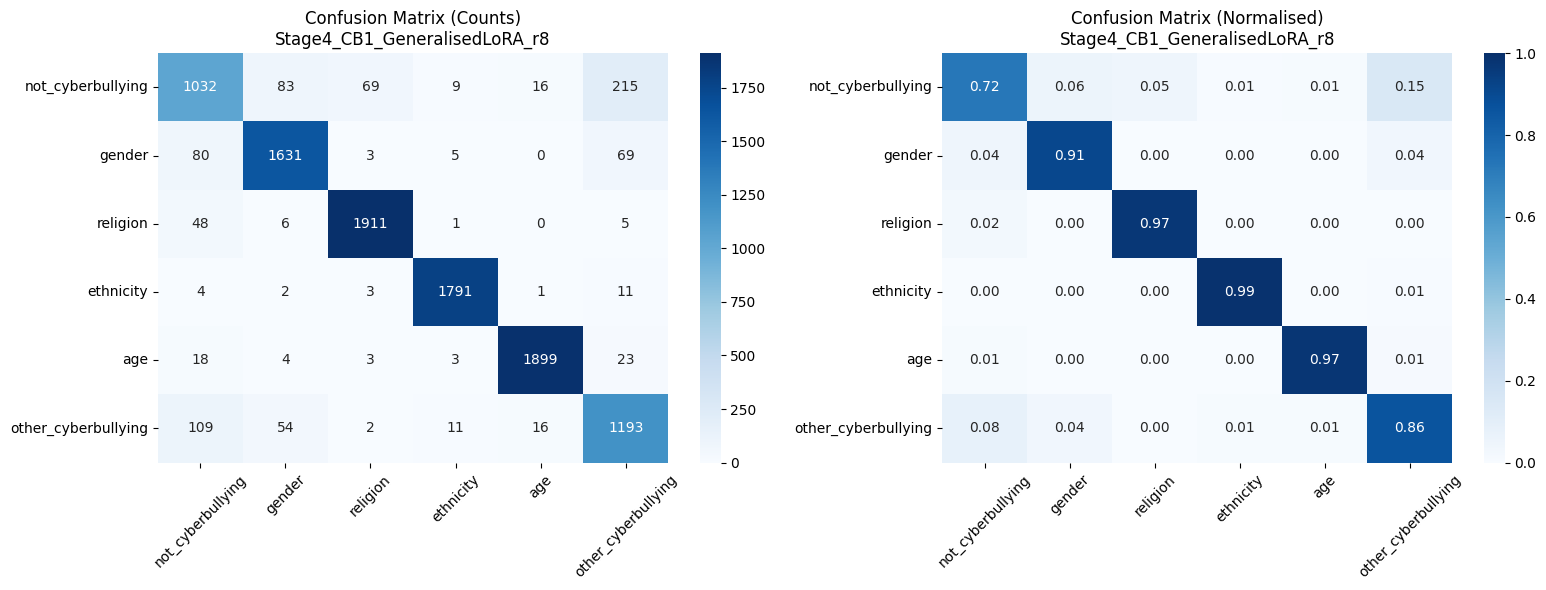


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r8

-------------------------------------------------------
  Rank sweep: r=16
-------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r16
  Model: google/gemma-2-9b-it  |  Rank: 16  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...
   Vocab: 256,000
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 168 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 37,868,544 | Total: 5,117,797,888 | 0.7399%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=16)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.690000,1.182173,0.805513,0.764263,0.773866
400,0.715700,0.545581,0.866101,0.851728,0.839285
600,0.657600,0.889013,0.839746,0.793450,0.814234
800,0.920100,0.667173,0.822478,0.801095,0.797798
1000,0.422000,0.559855,0.874886,0.856260,0.851649
1200,0.695500,0.571508,0.860345,0.835511,0.838630
1400,0.629600,0.665943,0.846410,0.822525,0.821628
1600,0.755600,0.469484,0.879733,0.865268,0.856616
1800,0.660400,0.618832,0.855801,0.839945,0.829925
2000,0.584800,0.520006,0.883975,0.871669,0.861765


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

   Time: 12790s (3.55 hrs)
   VALIDATION Macro F1 — best: 0.9127 | final: 0.9127   <-- rank selection uses THIS, not the test score
   Stability: 0.2118  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r16/stability_GeneralisedLoRA_r16.png


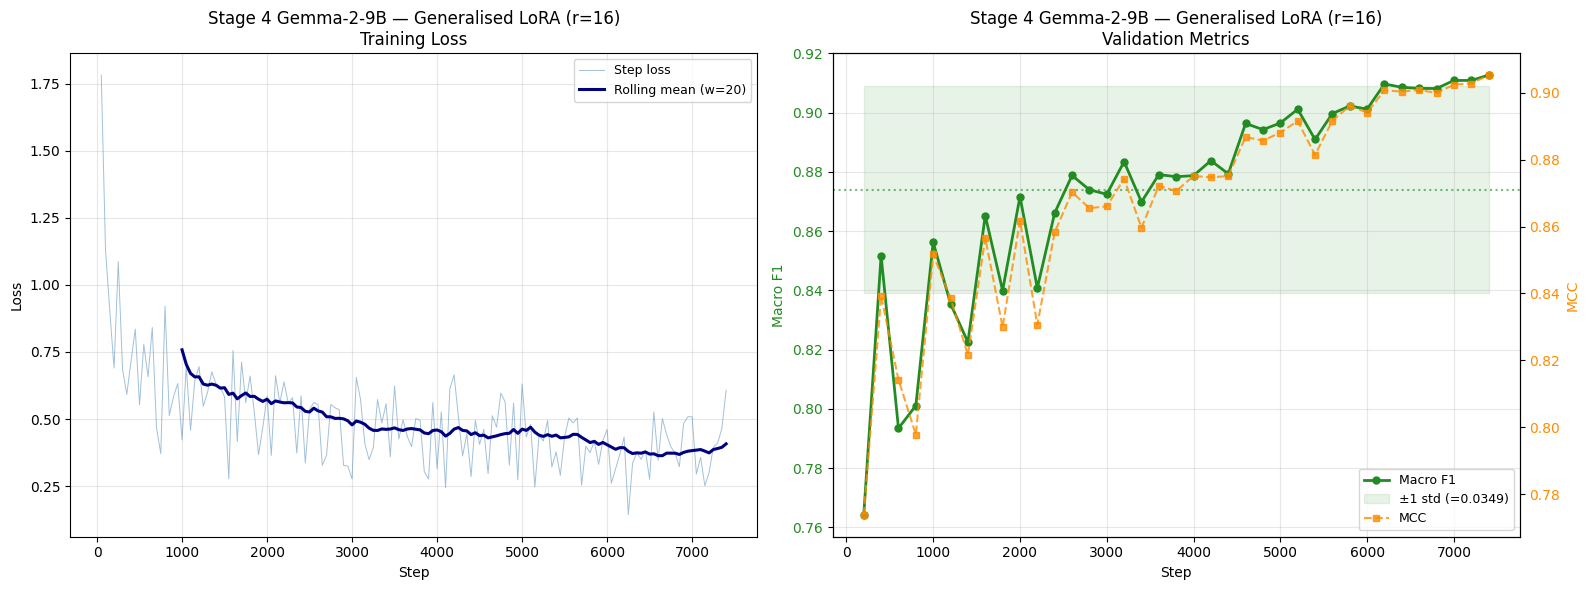


[6] Computing effective rank...

[6b] Rank-preservation conditions (Proposition 2):
      layers measured      : 168
      max ||UV||_2         : 6.0034   (needs < 1)
      satisfying Prop 2    : 1.2% of layers
      min sigma_min(I+UV)  : 1.6875e-01
      max condition number : 32.51
      NOTE: training left the Proposition 2 regime in some layers.
            Report this. It is a finding, not a failure.
   Eff.Rank Wf: 2815.98  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 16.00 | AB: 16.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9098
  Macro F1          : 0.8984  ← PRIMARY METRIC
  Weighted F1       : 0.9097
  Balanced Accuracy : 0.8990
  MCC               : 0.8915  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  

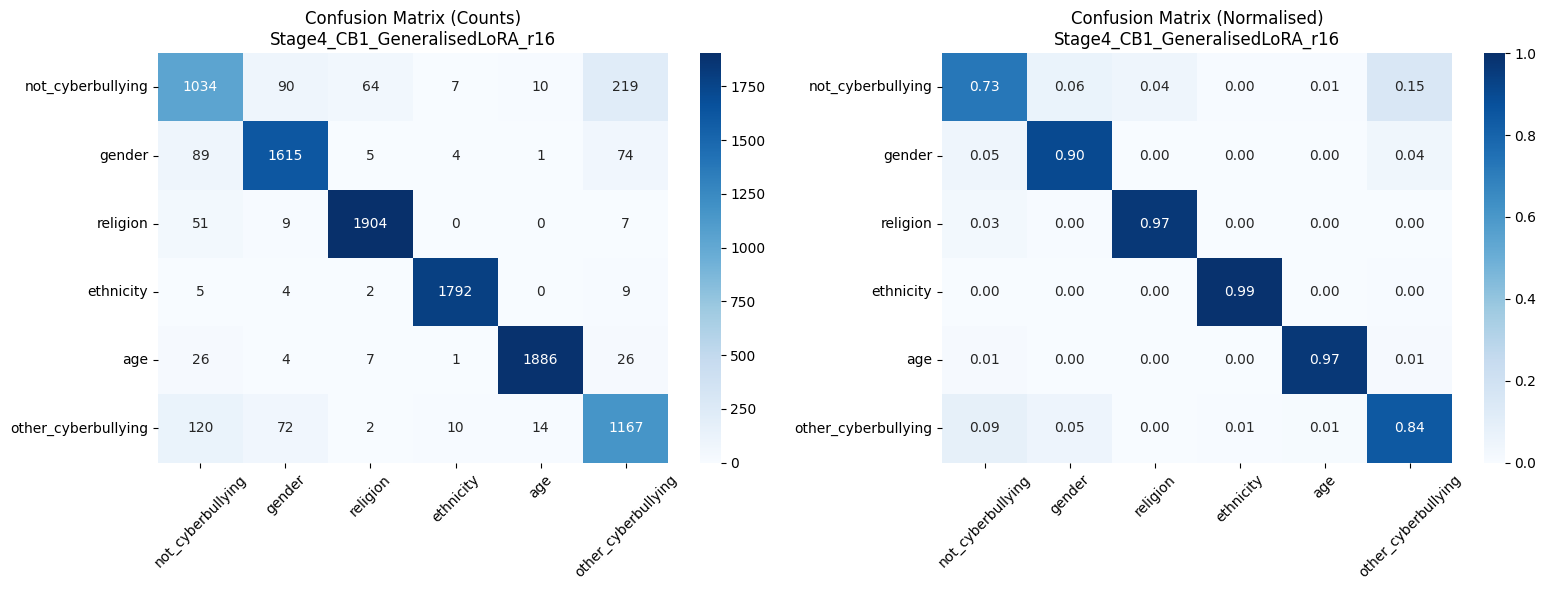


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r16

-------------------------------------------------------
  Rank sweep: r=32
-------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r32
  Model: google/gemma-2-9b-it  |  Rank: 32  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...
   Vocab: 256,000
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 168 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 75,715,584 | Total: 5,155,644,928 | 1.4686%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=32)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.760500,0.905843,0.817025,0.796466,0.784997
400,0.713400,1.015929,0.811875,0.771632,0.779939
600,0.643800,1.003422,0.835201,0.795164,0.806107
800,0.849700,0.495612,0.854287,0.841007,0.826258
1000,0.560700,0.766870,0.856104,0.831741,0.829554
1200,0.934200,0.516919,0.846713,0.829942,0.817716
1400,0.727000,0.753049,0.817025,0.776863,0.792471
1600,0.893900,0.561823,0.849743,0.836949,0.823469
1800,0.545800,0.866645,0.829749,0.789814,0.806497
2000,0.675600,0.806400,0.818540,0.784830,0.796233


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

   Time: 12801s (3.56 hrs)
   VALIDATION Macro F1 — best: 0.8933 | final: 0.8910   <-- rank selection uses THIS, not the test score
   Stability: 0.1889  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r32/stability_GeneralisedLoRA_r32.png


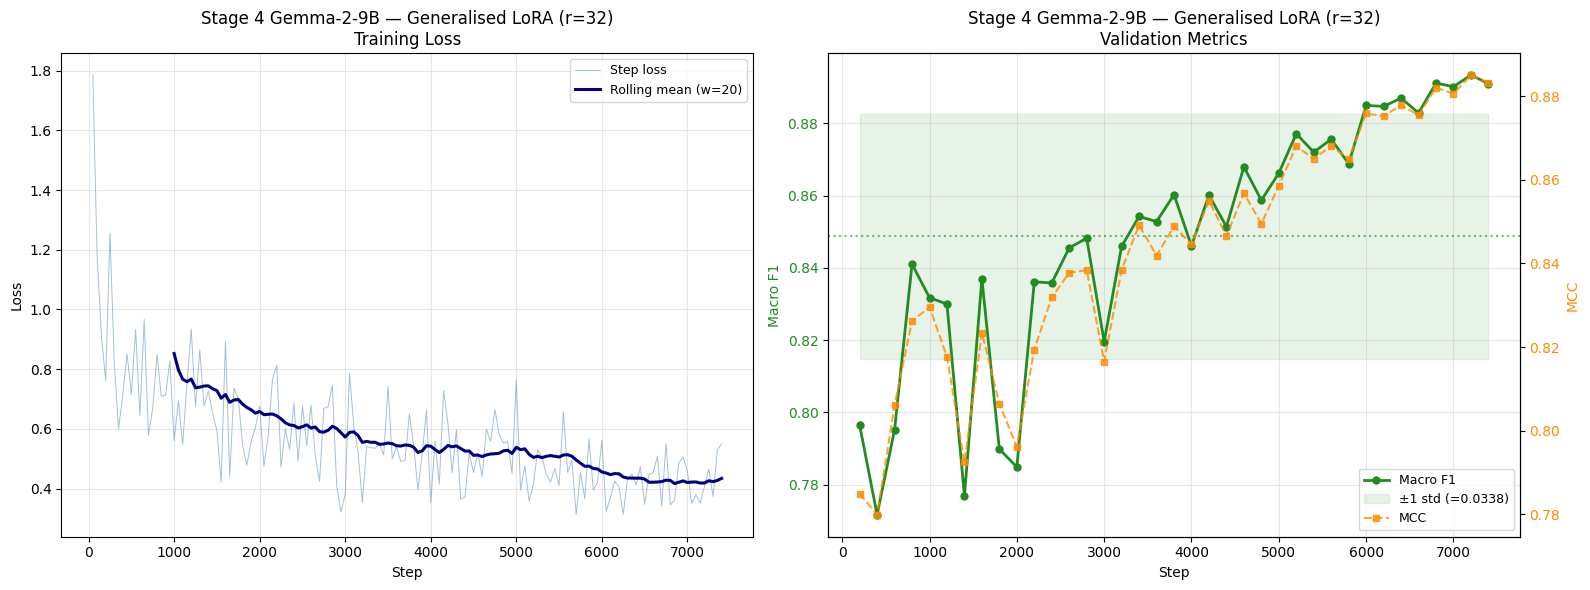


[6] Computing effective rank...

[6b] Rank-preservation conditions (Proposition 2):
      layers measured      : 168
      max ||UV||_2         : 10.6362   (needs < 1)
      satisfying Prop 2    : 0.0% of layers
      min sigma_min(I+UV)  : 9.2394e-02
      max condition number : 94.22
      NOTE: training left the Proposition 2 regime in some layers.
            Report this. It is a finding, not a failure.
   Eff.Rank Wf: 2815.55  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 32.00 | AB: 32.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8903
  Macro F1          : 0.8747  ← PRIMARY METRIC
  Weighted F1       : 0.8892
  Balanced Accuracy : 0.8757
  MCC               : 0.8683  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

 

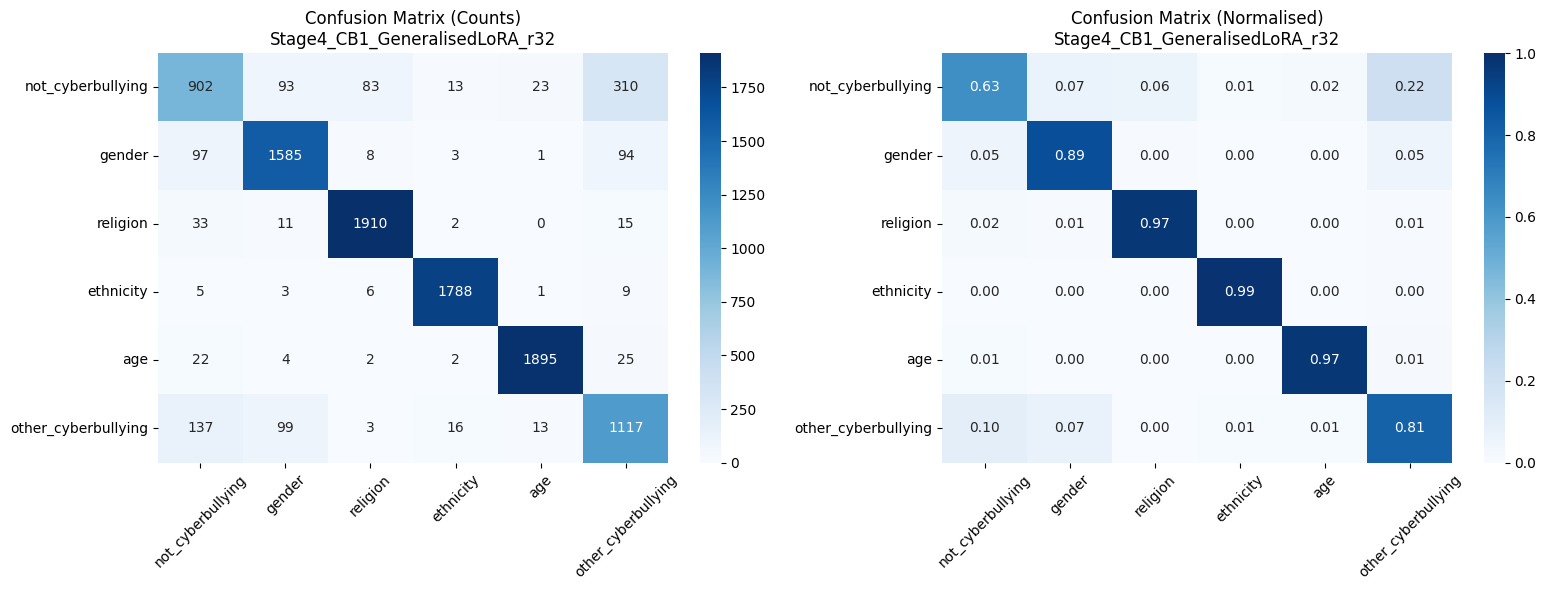


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r32

STAGE 4 — CB1 — Gemma-2-9B — RANK SELECTED ON VALIDATION
   r |    Trainable |  VAL Macro F1 |  TEST Macro F1 |     MCC | max||UV||2 | Selected
------------------------------------------------------------------------------------------------
   4 |    9,483,264 |        0.9160 |         0.9064 |  0.9002 |     2.2202 |
   8 |   18,945,024 |        0.9189 |         0.9044 |  0.8984 |     3.3587 |  <-- SELECTED
  16 |   37,868,544 |        0.9127 |         0.8984 |  0.8915 |     6.0034 |
  32 |   75,715,584 |        0.8933 |         0.8747 |  0.8683 |    10.6362 |
------------------------------------------------------------------------------------------------
Selected r=8 on validation (0.9189). Reported test Macro F1 = 0.9044.
Test scores at non-selected ranks are shown for transparency and played no part in selection.

>> Use r=8 for the Stage 4 multi-seed runs.

Saved: stage4_cb1_gemma9b

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# RUNS 2-4  —  r = 8, 16, 32     (~10.5 hrs; leave it running)
# ═══════════════════════════════════════════════════════════════════════════
for rank in [8, 16, 32]:
    print(f'\n{"-"*55}\n  Rank sweep: r={rank}\n{"-"*55}')
    all_rank_results[rank] = run_generalised_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=rank, run_label=f'GeneralisedLoRA_r{rank}')

# ---- RANK SELECTED ON VALIDATION (Reviewers 5a, 6b) -----------------------
ranks = sorted(all_rank_results)
best_rank = max(ranks, key=lambda r: all_rank_results[r]['val_macro_f1_best'])

print(f'\n{"="*96}')
print('STAGE 4 — CB1 — Gemma-2-9B — RANK SELECTED ON VALIDATION')
print(f'{"="*96}')
print(f'{"r":>4} | {"Trainable":>12} | {"VAL Macro F1":>13} | {"TEST Macro F1":>14} | {"MCC":>7} | {"max||UV||2":>10} | Selected')
print('-'*96)
for r in ranks:
    x = all_rank_results[r]
    d = x.get('rank_diagnostics') or {}
    mark = '  <-- SELECTED' if r == best_rank else ''
    print(f'{r:>4} | {x["trainable_params"]:>12,} | {x["val_macro_f1_best"]:>13.4f} | '
          f'{x["macro_f1"]:>14.4f} | {x["mcc"]:>7.4f} | '
          f'{d.get("max_spectral_norm_UV", float("nan")):>10.4f} |{mark}')
print('-'*96)
sel = all_rank_results[best_rank]
print(f'Selected r={best_rank} on validation ({sel["val_macro_f1_best"]:.4f}). '
      f'Reported test Macro F1 = {sel["macro_f1"]:.4f}.')
print('Test scores at non-selected ranks are shown for transparency and played no part in selection.')
print(f'\n>> Use r={best_rank} for the Stage 4 multi-seed runs.')

import pandas as _pd, os as _os
_pd.DataFrame([{ 'rank': r, **{k: all_rank_results[r].get(k) for k in
                 ('val_macro_f1_best','val_macro_f1_final','macro_f1','mcc','trainable_params')},
                 **(all_rank_results[r].get('rank_diagnostics') or {}) } for r in ranks]
).to_csv(_os.path.join(OUTPUT_DIR, 'stage4_cb1_gemma9b_rank_sweep_VALIDATION_SELECTED.csv'), index=False)
print('\nSaved: stage4_cb1_gemma9b_rank_sweep_VALIDATION_SELECTED.csv')


## Step 13b: Recovery — only if the session dropped

Rebuilds `all_rank_results` from the per-run CSVs already saved in Drive, so it does not
have to repeat finished runs. Run Step 1 → restart → Steps 2 to 11 first, then this.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Step 13b — RECOVERY (only needed if Colab disconnected)
# Completed runs already wrote their results to Drive. This rebuilds the
# in-memory dict from those files so Step 14 works and only reruns what
# is actually missing.
# ═══════════════════════════════════════════════════════════════════════════
import glob, os, pandas as pd

all_rank_results = {}
for path in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*', '*_results.csv'))):
    df = pd.read_csv(path)
    if df.empty:
        continue
    row = df.iloc[0].to_dict()
    r = int(row['rank'])
    diag_keys = ('max_spectral_norm_UV','mean_spectral_norm_UV',
                 'frac_layers_satisfying_prop2','min_sigma_min_L1',
                 'max_cond_L1','mean_cond_L1')
    row['rank_diagnostics'] = {k: row.get(k) for k in diag_keys if k in row}
    all_rank_results[r] = row
    print(f'  recovered r={r:>2}: val={row.get("val_macro_f1_best", float("nan")):.4f} | '
          f'test={row.get("macro_f1", float("nan")):.4f}')

done    = sorted(all_rank_results)
missing = [r for r in (4, 8, 16, 32) if r not in all_rank_results]
print(f'\nRecovered ranks : {done}')
print(f'Still missing   : {missing if missing else "none — go straight to Step 14"}')

if any('val_macro_f1_best' not in v for v in all_rank_results.values()):
    print('\nWARNING: a recovered run predates the validation-logging patch.')
    print('         It must be rerun, or the rank cannot be selected on validation.')

if missing:
    print(f'\nTo finish, run only the missing ranks:')
    print(f'  for rank in {missing}:')
    print(f"      all_rank_results[rank] = run_generalised_lora(")
    print(f"          train_df=train_df, val_df=val_df, test_df=test_df,")
    print(f"          lora_rank=rank, run_label=f'GeneralisedLoRA_r{{rank}}')")


---
## Step 14: Final Summary

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# Step 14 — FINAL SUMMARY
# CHANGED FOR THE REVISION: this cell previously chose best_r on TEST Macro F1,
# which is the exact thing Prior evaluation practice(a) and 6(b) objected to. It now selects
# on validation and reports test only for the selected rank.
# ═══════════════════════════════════════════════════════════════════════════
print('\n' + '═'*70)
print('  STAGE 4a COMPLETE — GENERALISED LoRA | Gemma-2-9B-IT')
print('  Formula: Wf = W(I + UV) + AB  |  CB1 6-Class')
print('═'*70)

best_r = max(all_rank_results, key=lambda r: all_rank_results[r]['val_macro_f1_best'])
best   = all_rank_results[best_r]
diag   = best.get('rank_diagnostics') or {}

print(f'\n── SELECTED ON VALIDATION: r={best_r} ──')
print(f'  Validation Macro F1 : {best["val_macro_f1_best"]:.4f}   ← SELECTION METRIC')
print(f'  Test Macro F1       : {best["macro_f1"]:.4f}   ← reported, not used to select')
print(f'  MCC                 : {best["mcc"]:.4f}')
print(f'  Trainable params    : {best["trainable_params"]:,}')
print(f'  Eff. rank (Wf)      : {best["avg_eff_rank_Wf"]:.2f}')
print(f'  Stability           : {best["stability_score"]:.4f}')
print(f'  Time                : {best["train_runtime_s"]/3600:.2f} hrs')
if diag:
    print(f'  max ||UV||_2        : {diag.get("max_spectral_norm_UV", float("nan")):.4f}   (Prop. 2 needs < 1)')
    print(f'  layers satisfying   : {100*diag.get("frac_layers_satisfying_prop2", float("nan")):.1f}%')

print('\n── ALL RANKS (transparency; selection used validation only) ──')
for r in sorted(all_rank_results):
    x = all_rank_results[r]
    tag = '  <-- selected' if r == best_r else ''
    print(f'  r={r:>2}: val={x["val_macro_f1_best"]:.4f} | test={x["macro_f1"]:.4f} | '
          f'params={x["trainable_params"]:>11,}{tag}')

print('\n── FOR THE RESPONSE LETTER ──')
print(f'  Rank selected using validation Macro F1 alone.')
print(f'  Test set used once, to report the selected configuration.')
print(f'  Old paper reported r=4 at test F1 0.9082, chosen on test.')
print(f'  New selection: r={best_r}, chosen on validation, test F1 {best["macro_f1"]:.4f}.')
if best_r == 4:
    print('  >> Same rank as before. The headline number survives; only the')
    print('     selection procedure changed. This is the best possible outcome.')
else:
    print(f'  >> DIFFERENT rank from the paper (was r=4). The headline number changes.')
    print('     Report this transparently, since the selected rank must not depend on the test set.')

print('\n>> Next: run Stages 2 and 3 sweeps, then multi-seed all three at their selected ranks.')



══════════════════════════════════════════════════════════════════════
  STAGE 4a COMPLETE — GENERALISED LoRA | Gemma-2-9B-IT
  Formula: Wf = W(I + UV) + AB  |  CB1 6-Class
══════════════════════════════════════════════════════════════════════

── SELECTED ON VALIDATION: r=8 ──
  Validation Macro F1 : 0.9189   ← SELECTION METRIC
  Test Macro F1       : 0.9044   ← reported, not used to select
  MCC                 : 0.8984
  Trainable params    : 18,945,024
  Eff. rank (Wf)      : 2815.98
  Stability           : 0.2259
  Time                : 3.46 hrs
  max ||UV||_2        : 3.3587   (Prop. 2 needs < 1)
  layers satisfying   : 3.6%

── ALL RANKS (transparency; selection used validation only) ──
  r= 4: val=0.9160 | test=0.9064 | params=  9,483,264
  r= 8: val=0.9189 | test=0.9044 | params= 18,945,024  <-- selected
  r=16: val=0.9127 | test=0.8984 | params= 37,868,544
  r=32: val=0.8933 | test=0.8747 | params= 75,715,584

── FOR THE RESPONSE LETTER ──
  Rank selected using validation Ma